### Dependencies

In [1]:
%pip install scikit-learn
%pip install numpy
%pip install matplotlib
%pip install pyod
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached torch-2.9.0-cp312-cp312-win_amd64.whl.metadata (30 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2025.10.0-py3-none-any.whl.metadata (10 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
Using cached torch-2.9.0-cp312-cp312-win_amd64.whl (109.3 MB)
Using cached fsspec-2025.10.0-py3-none-any.whl (200 kB)
Using cached networkx-3.5-py3-none-any.whl (2.0 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
Using cached filelock-3.20.0-py3-none-any.w


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from sklearn.datasets import make_blobs
import numpy as np
from sklearn.preprocessing import Normalizer
import matplotlib.pyplot as plt
from pyod.models.iforest import IForest
from pyod.models.dif import DIF
from pyod.models.loda import LODA

### Exercise 1

In [3]:
def ex1_1():
    num_samples = 500
    miu = [0.0, 0.0]
    sigma = [1.0, 1.0]
    
    dataset = make_blobs(n_samples=num_samples,
        centers=[miu], cluster_std=[sigma],
        n_features=2, random_state=23)

    return dataset


dataset_ex1_1 = ex1_1()
X_ex1 = dataset_ex1_1[0]
Y_ex1 = dataset_ex1_1[1]
print(f'X Shape: {X_ex1.shape}')
print(f'Y Shape: {Y_ex1.shape}')

X Shape: (500, 2)
Y Shape: (500,)


projection_vectors norms: [1. 1. 1. 1. 1.]


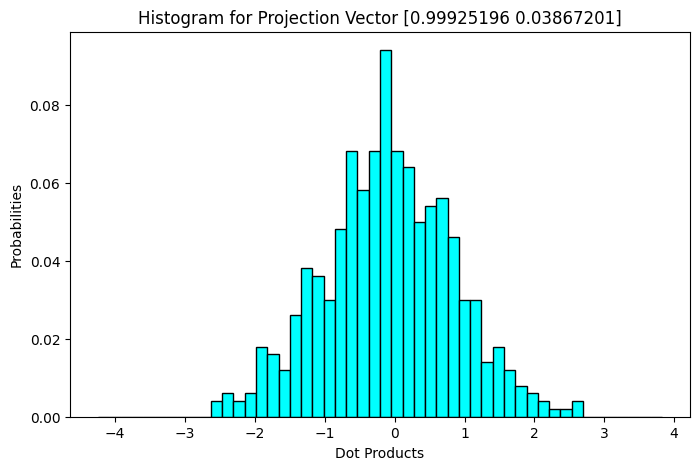

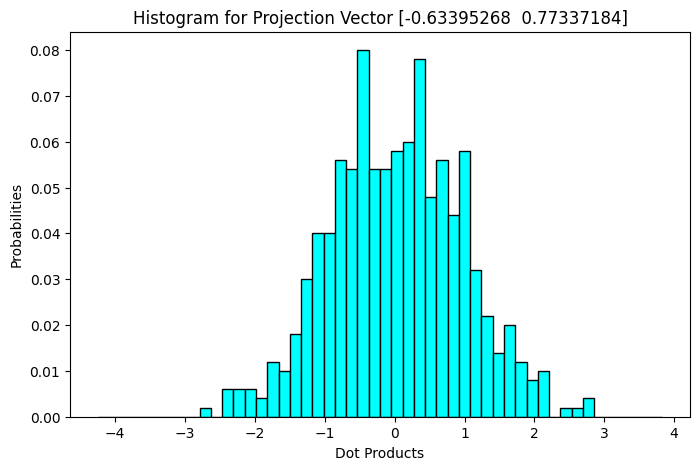

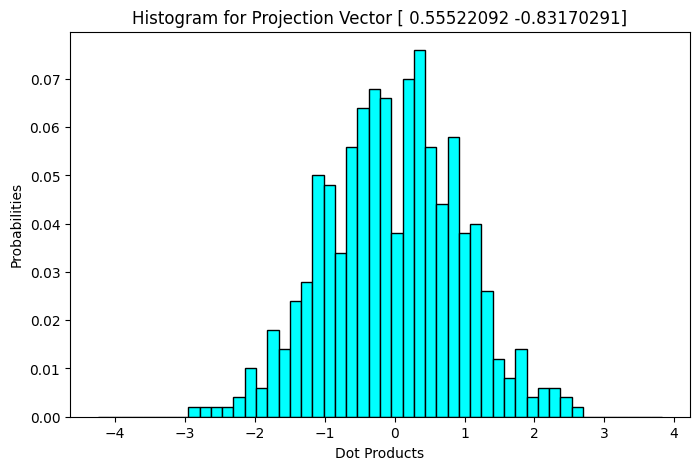

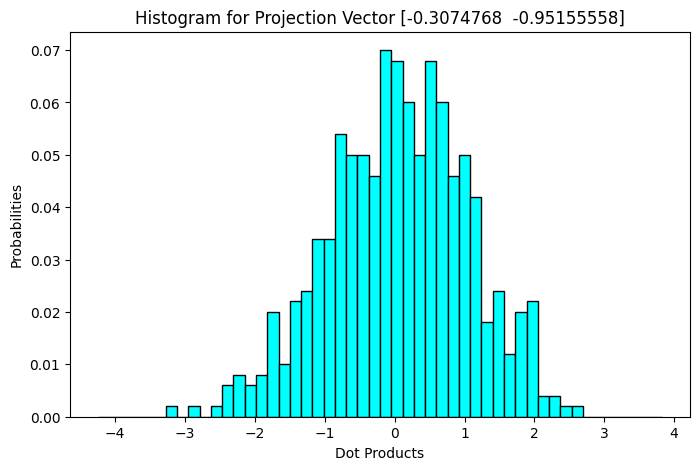

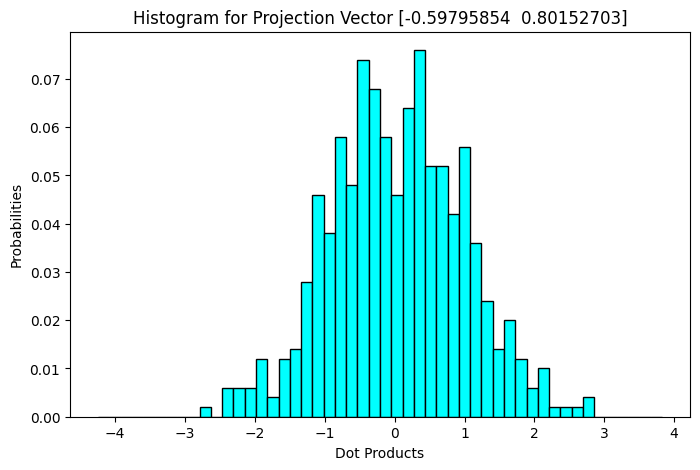

In [4]:
def ex1_2(X, num_bins, plot):
    num_projection_vectors = 5

    mean = [0.0, 0.0]
    covariance = [[1.0, 0.0], [0.0, 1.0]]

    np.random.seed(23)
    projection_vectors = np.random.multivariate_normal(mean=mean, 
        cov=covariance, size=num_projection_vectors)

    normalizer = Normalizer(norm='l2')
    normalizer.fit(projection_vectors)
    projection_vectors = normalizer.transform(projection_vectors)

    print(f'projection_vectors norms: {np.linalg.norm(projection_vectors, ord=2, axis=1)}')

    X_projections = np.dot(X, projection_vectors.T)

    proj_min = np.min(X_projections)
    proj_max = np.max(X_projections)

    delta = 1.0
    val_range = (proj_min - delta, proj_max + delta)

    probs_per_proj = np.zeros((X.shape[0], num_projection_vectors))

    for proj_idx, proj_vect in enumerate(projection_vectors):
        X_proj = X_projections[:, proj_idx]

        counts, edges = np.histogram(X_proj, bins=num_bins, range=val_range)
        probabilities = counts.astype(float) / np.sum(counts)

        bin_centers = (edges[:-1] + edges[1:]) / 2.0
        bin_width = edges[1] - edges[0]

        if plot:
            plt.figure(figsize=(8, 5))
            plt.bar(bin_centers, probabilities, width=bin_width,
                color='cyan', edgecolor='black')
            plt.title(f'Histogram for Projection Vector {proj_vect}')
            plt.xlabel('Dot Products')
            plt.ylabel('Probabilities')
            plt.show()

        bin_indices = np.digitize(X_proj, edges) - 1  # np.digitize() e 1-indexed
        bin_indices = np.clip(bin_indices, 0, num_bins - 1)
        probs_per_proj[:, proj_idx] = probabilities[bin_indices]

    normality_scores = np.mean(probs_per_proj, axis=1)
    epsilon = 1e-8
    anomaly_scores = -np.log(normality_scores + epsilon)

    return anomaly_scores


anomaly_scores_ex1_2 = ex1_2(X_ex1, num_bins=50, plot=True)

projection_vectors norms: [1. 1. 1. 1. 1.]


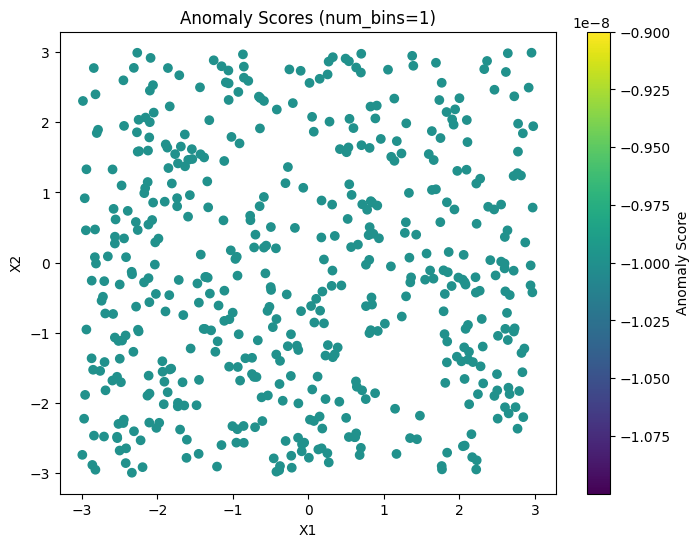

projection_vectors norms: [1. 1. 1. 1. 1.]


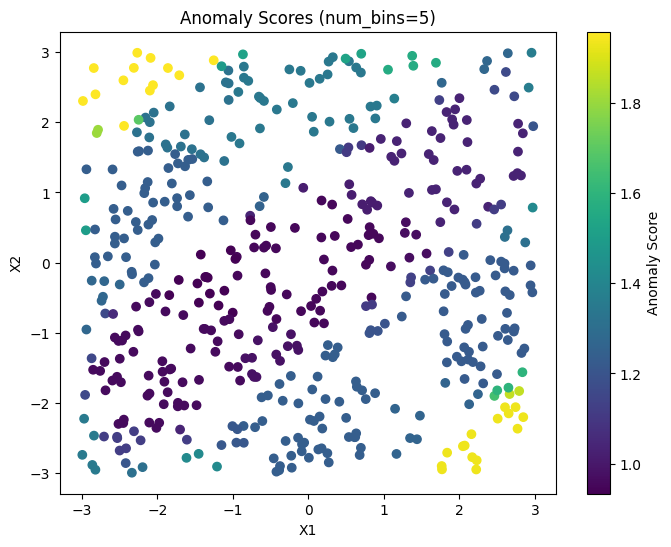

projection_vectors norms: [1. 1. 1. 1. 1.]


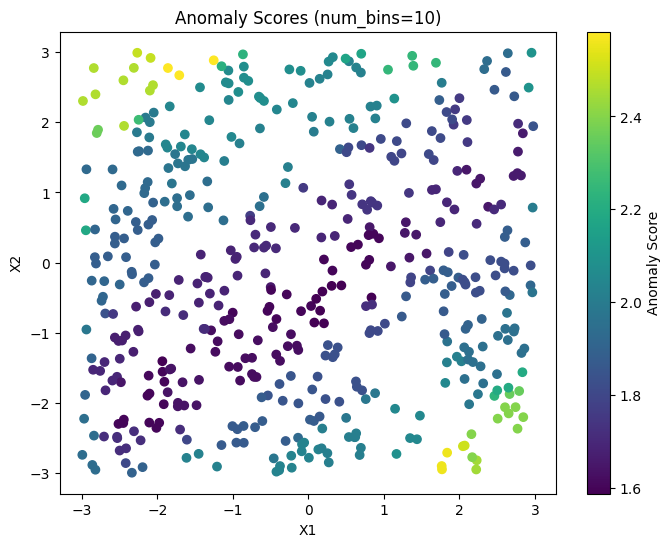

projection_vectors norms: [1. 1. 1. 1. 1.]


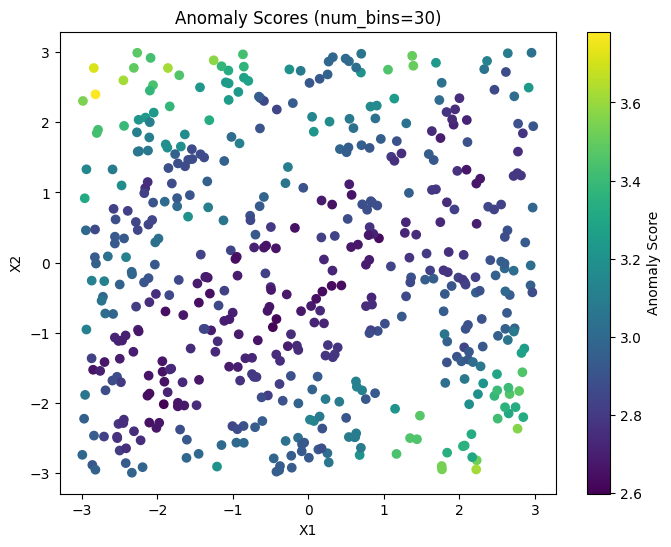

projection_vectors norms: [1. 1. 1. 1. 1.]


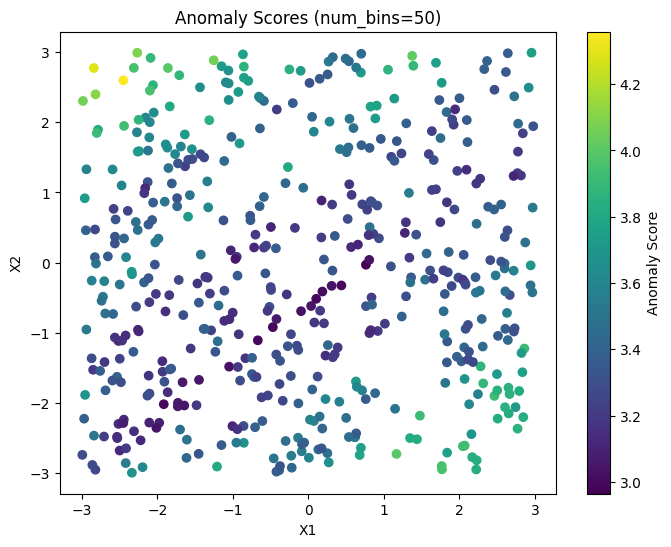

projection_vectors norms: [1. 1. 1. 1. 1.]


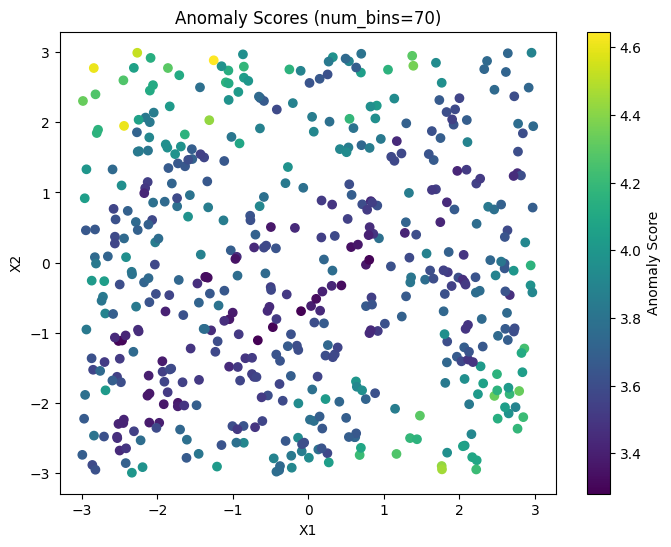

projection_vectors norms: [1. 1. 1. 1. 1.]


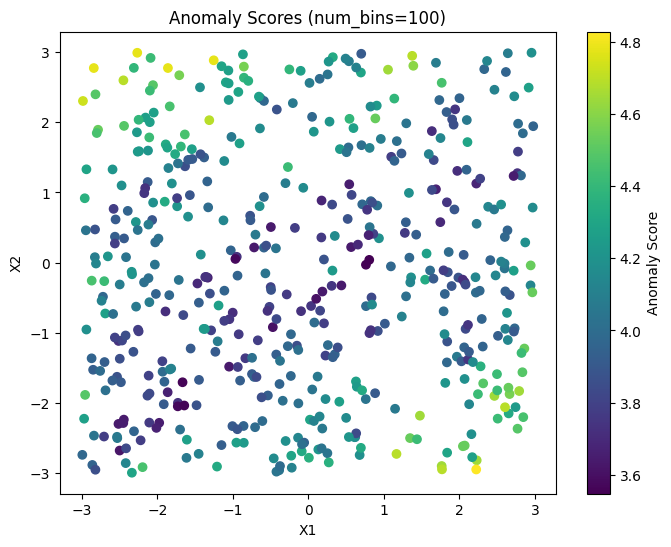

In [5]:
def ex1_3():
    num_samples = 500
    low = -3.0
    high = 3.0

    X = np.random.uniform(low=low, high=high, size=(num_samples, 2))

    nums_bins = [1, 5, 10, 30, 50, 70, 100]
    for num_bins in nums_bins:
        anomaly_scores = ex1_2(X, num_bins=num_bins, plot=False)

        plt.figure(figsize=(8, 6))
        plt.scatter(X[:, 0], X[:, 1], c=anomaly_scores)
        plt.colorbar(label='Anomaly Score')
        plt.title(f'Anomaly Scores (num_bins={num_bins})')
        plt.xlabel('X1')
        plt.ylabel('X2')
        plt.show()


ex1_3()

### Conclusion:
The anomaly scores go up as we increase the number of bins.

### Exercise 2

Dataset Shape: (500, 2)


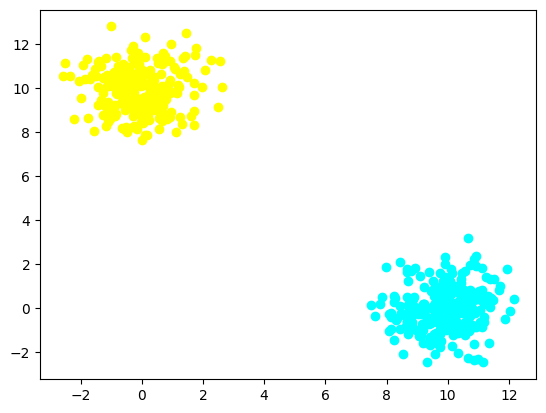

In [6]:
def ex2_1():
    num_samples = 500
    mius = [[10.0, 0.0], [0.0, 10.0]]
    sigmas = [[1.0, 1.0], [1.0, 1.0]]

    dataset = make_blobs(n_samples=num_samples,
        centers=mius, cluster_std=sigmas,
        n_features=2, random_state=23, shuffle=True)

    X = dataset[0]
    Y = dataset[1]

    plt.scatter(X[Y == 0][:, 0], X[Y == 0][:, 1], c='cyan')
    plt.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], c='yellow')

    return dataset


dataset_ex2_1 = ex2_1()
X_ex2 = dataset_ex2_1[0]
Y_ex2 = dataset_ex2_1[1]
print(f'Dataset Shape: {X_ex2.shape}')

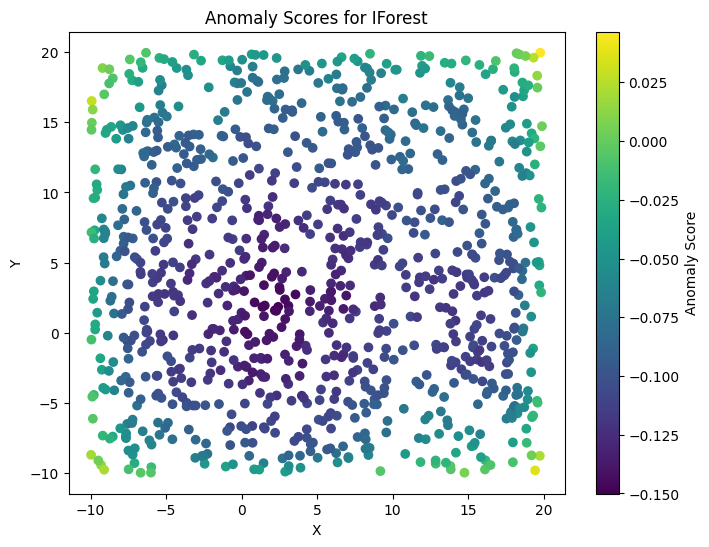

In [7]:
def ex2_2():
    num_samples = 1000
    low = -10.0
    high = 20.0

    X = np.random.uniform(low=low, high=high, size=(num_samples, 2))

    i_forest = IForest(contamination=0.02, random_state=23)
    i_forest.fit(X)

    anomaly_scores = i_forest.decision_function(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=anomaly_scores)
    plt.colorbar(label='Anomaly Score')
    plt.title(f'Anomaly Scores for IForest')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()


ex2_2()

We can see that since the threshold lines of the isolation forest are axis aligned, the points in the corners have higher anomaly scores even if they are at the same distance from the center at points in extreme left-right-top-bottom.

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't

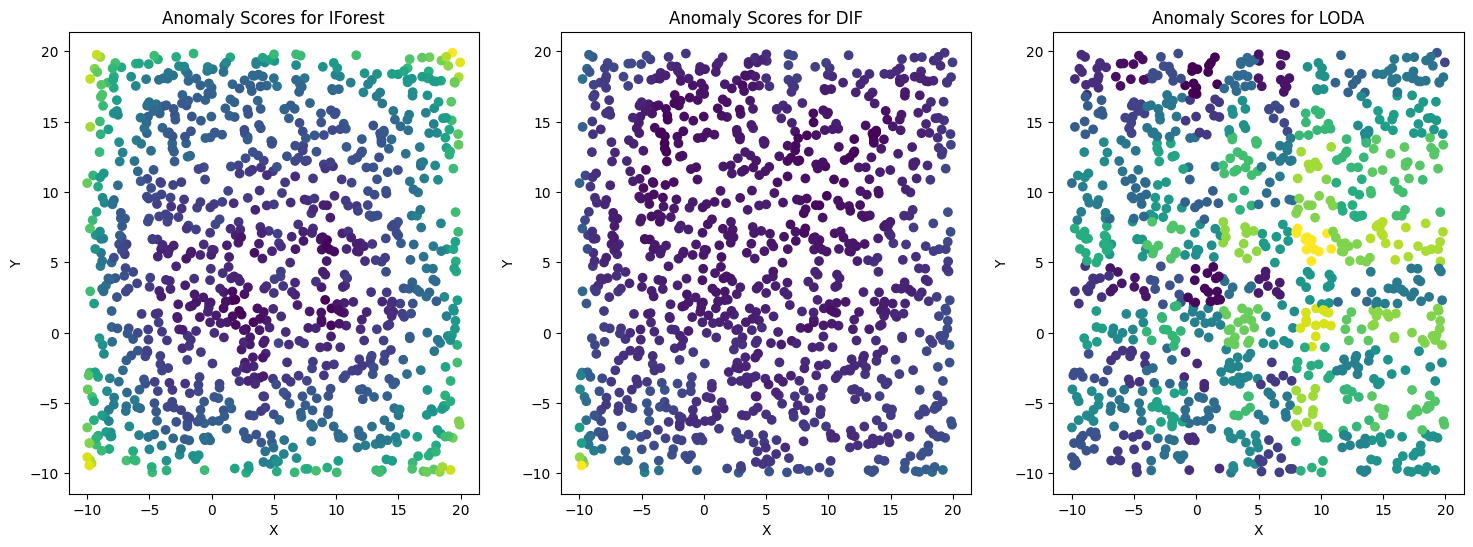

In [9]:
def ex2_4():
    num_samples = 1000
    low = -10.0
    high = 20.0

    X = np.random.uniform(low=low, high=high, size=(num_samples, 2))

    i_forest = IForest(contamination=0.02, random_state=23)
    i_forest.fit(X)

    anomaly_scores_i_forest = i_forest.decision_function(X)

    dif = DIF(contamination=0.02, random_state=23)
    dif.fit(X)

    anomaly_scores_dif = dif.decision_function(X)

    loda = LODA(contamination=0.02)
    loda.fit(X)

    anomaly_scores_loda = loda.decision_function(X)

    _, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes = axes.flatten()

    axes[0].scatter(X[:, 0], X[:, 1], c=anomaly_scores_i_forest)
    axes[0].set_title(f'Anomaly Scores for IForest')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    # axes[0].legend()

    axes[1].scatter(X[:, 0], X[:, 1], c=anomaly_scores_dif)
    axes[1].set_title(f'Anomaly Scores for DIF')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    # axes[1].legend()

    axes[2].scatter(X[:, 0], X[:, 1], c=anomaly_scores_loda)
    axes[2].set_title(f'Anomaly Scores for LODA')
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('Y')
    # axes[2].legend()

    plt.show()


ex2_4()